In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download mohamedhanyyy/chest-ctscan-images

Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
100% 119M/119M [00:01<00:00, 119MB/s]



In [3]:
import zipfile
zip = zipfile.ZipFile("/content/chest-ctscan-images.zip",'r')
zip.extractall("/content")
zip.close()

In [4]:
import numpy as np
import pandas as pd
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.models import Sequential
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
!pip install mpimg

  Preparing metadata (setup.py) ... done
  Created wheel for mpimg: filename=mpimg-0.0.1-py3-none-any.whl size=1328 sha256=792fcfad06038676a189aab1651d1811ae1ef476c4a99fd49fb4e4736d5cf8b5
  Stored in directory: /root/.cache/pip/wheels/cf/b7/30/6e1f95494bf160c79071cc4ed9f544789ab046c23e4775bbf5
Successfully built mpimg


(264, 409, 4)

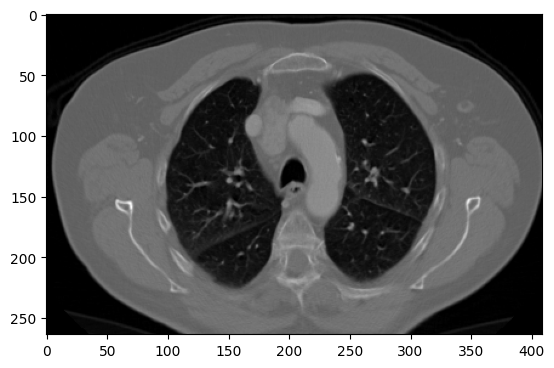

In [6]:
img_path="/content/Data/train/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/000000 (6).png"
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img=mpimg.imread(img_path)
plt.imshow(img)
img.shape


In [7]:
image_size=224
batch_size=32

In [8]:
#data generator
data_gen=ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

In [9]:
#train generator
train_gen=data_gen.flow_from_directory(
    directory='/content/Data/train',
    target_size=(image_size,image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'

)

Found 491 images belonging to 4 classes.


In [10]:
#val generator
val_gen=data_gen.flow_from_directory(
    directory="/content/Data/valid",
    target_size=(image_size,image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',

)

Found 13 images belonging to 4 classes.


In [11]:
#test generator
test_gen=data_gen.flow_from_directory(
    directory="/content/Data/test",
    target_size=(image_size,image_size),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 315 images belonging to 4 classes.


In [ ]:
# import tensorflow as tf
# from tensorflow.keras import layers

# # Redefine explicitly for 3-channel (RGB) images
# medical_augmentation = tf.keras.Sequential([
#     layers.Input(shape=(224, 224, 3)), # <--- CRITICAL: Changed from 4 to 3 here
#     layers.RandomFlip("horizontal_and_vertical"),
#     layers.RandomRotation(factor=0.25, fill_mode="reflect"),
#     layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05))
# ])


In [12]:
#model building
model=Sequential()
# model.add(medical_augmentation)
model.add(Conv2D(32,kernel_size=(3,3),input_shape=(image_size,image_size,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(Conv2D(128,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 107, 107, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 359552)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    46,022,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,116,548 (175.92 MB)

 Trainable params: 46,116,548 (175.92 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [15]:
history=model.fit(train_gen,steps_per_epoch=train_gen.samples//batch_size,epochs=10,validation_data=val_gen,
                  validation_steps=val_gen.samples//batch_size)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 584ms/step - accuracy: 0.3268 - loss: 4.1346 - val_accuracy: 0.3846 - val_loss: 1.2227
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3438 - loss: 1.2125 - val_accuracy: 0.1538 - val_loss: 1.2670
Epoch 3/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.5839 - loss: 0.9539 - val_accuracy: 0.6923 - val_loss: 0.9437
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8125 - loss: 0.6705 - val_accuracy: 0.4615 - val_loss: 1.1074
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.7821 - loss: 0.5697 - val_accuracy: 0.6923 - val_loss: 0.8307
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9062 - loss: 0.2932 - val_accuracy: 0.6923 - val_loss: 0.8428
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.8867 - loss: 0.3422 - val_accuracy: 0.6154 - val_loss: 1.1142
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9062 - loss: 0.3118 - val_accuracy: 0.6154 - val_loss: 1.0853
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.9325 - loss: 0.1953 - val_accuracy: 0.6923 - val_loss: 0.9907
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0595 - val_accuracy: 0.6923 - val_loss: 1

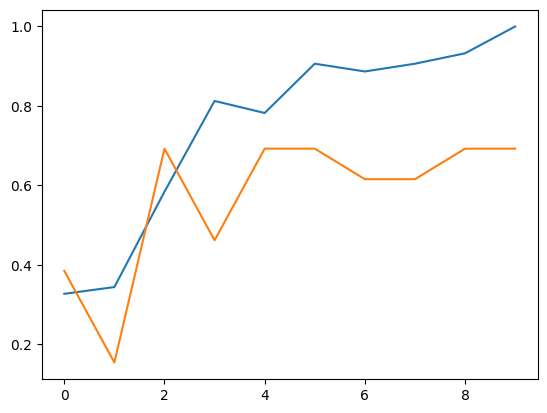

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [18]:

# 2. Evaluate performance
print("\n--- Evaluating on Test Data ---")
test_loss, test_accuracy = model.evaluate(test_gen)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")


--- Evaluating on Test Data ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.4476 - loss: 2.5747
Final Test Accuracy: 44.76%


In [19]:

class_indices = {v: k for k, v in train_gen.class_indices.items()}

In [20]:
class_indices

{0: 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
 1: 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
 2: 'normal',
 3: 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'}

In [21]:
#prediction system
def load_and_preprocess_image(img_path,target_size=(224,224)):
 img=Image.open(img_path).convert("RGB")
 img=img.resize(target_size)
 img_array=np.array(img)
 img_array=np.expand_dims(img_array,axis=0)
 img_array=img_array.astype("float32")/255.0
 return img_array


def predict_img_class(model,img_path,class_indices):
  preprocessed_img=load_and_preprocess_image(img_path)
  prediction=model.predict(preprocessed_img)
  prediction_class_index=np.argmax(prediction,axis=1)[0]
  predict_lung_cancer=class_indices[prediction_class_index]
  return predict_lung_cancer




In [22]:
img_path="/content/Data/test/large.cell.carcinoma/000111 (2).png"
predict_lung_cancer=predict_img_class(model,img_path,class_indices)
print(predict_lung_cancer)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa


In [ ]:
import pickle
pickle.dump(model,open("model12",'wb'))

In [23]:
import pickle
pickle.dump(class_indices,open('class_indices12','wb'))